# M4ML: Project 2

Code appendix for Project Topic **7**: Mathematical Principles of Large Language Models (LLMs)

**Authors**: Diogo Manuel Cerieiro dos Santos (93635), Matěj Polák (119339)

June 2, 2026

In [140]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.6f}'.format)

In [132]:
def get_softmax(X, row_wise=True):
    exp_X = np.exp(X)
    return exp_X / np.sum(exp_X, axis=int(row_wise), keepdims=True)

def get_attention(Q, K, V, mask=True, bias_strength=0.0, debug=False):
    # 1. Compute attention scores
    scores = Q @ K.T
    if bias_strength:
        positions = np.arange(scores.shape[0])
        distance = np.abs(
            positions[:, None] - positions[None, :]
        )
        scores = scores - bias_strength * distance
    if debug:
        print('Raw attention scores:\n', scores)

    # 2. Scale by sqrt(dimension)
    scaled_scores = scores / np.sqrt(Q.shape[1])
    if debug:
        print('Scaled attention scores:\n', scaled_scores)

    # 3. Apply causal mask
    if mask:
        seq_len = scores.shape[0]

        causal_mask = np.triu(
            np.ones((seq_len, seq_len)),
            k=1
        ).astype(bool)

        scaled_scores[causal_mask] = -np.inf
        if debug:
            print('Attention scores after applying causal mask:\n', scaled_scores)

    # 4. Apply Softmax to get probabilities
    attention = get_softmax(scaled_scores)
    if debug:
        print('Attention probabilities:\n', np.round(attention, 3))

    # 5. Multiply by V
    out_embeddings = attention @ V
    if debug:
        print('Output embeddings:\n', np.round(out_embeddings, 3))

    return scaled_scores, attention, out_embeddings

In [204]:
# Dimensions: noun, modifier, preposition
vocab = {
    "alice":      np.array([10, 0, 0]),
    "tom":        np.array([10, 0, 0]),

    "her":        np.array([0, 9.5, 0]),
    "favorite":   np.array([0, 10, 0]),
    "the":        np.array([0, 3, 0]),
    "bedside":    np.array([0, 10, 0]),
    "dining":     np.array([0, 10, 0]),
    "neighbor's": np.array([0, 10, 0]),

    "book":       np.array([9, 0, 0]),
    "table":      np.array([9, 0, 0]),
    "garden":     np.array([9, 0, 0]),

    "on":         np.array([0, 0, 10]),
    "in":         np.array([0, 0, 10]),

    "put":        np.array([0, 0, 0]),
    "is":         np.array([0, 0, 0]),
    "are":        np.array([0, 0, 0]),
    "sitting":    np.array([0, 0, 0]),
    "playing":    np.array([0, 0, 0]),
    "and":        np.array([0, 0, 0]),
}

s0 = ["tom", "is", "in", "the", "garden"]
s1 = ["alice", "put", "her", "favorite", "book", "on", "the", "bedside", "table"]
s2 = ["alice", "is", "sitting", "on", "the", "dining", "table"]
s3 = ["alice", "and", "tom", "are", "playing", "in", "the", "neighbor's", "garden"]

## Part 1

Construct a simple numerical example (you can use small, fabricated matrices) to
demonstrate how the attention mechanism works in practice. Perform the
calculations manually or using a simple Python script.

In [206]:
sentence = s0
embedding = np.array([vocab[word] for word in s0])
print('Sentence:', s0)
print('Embedding:\n', embedding)

W_Q = np.array([
    [1, 0, 0, 1],
    [0, 1, 0, 0],
    [0, 0, 2, 1],
], dtype=float)

W_K = np.array([
    [1, 0, 0, 0],
    [0, 1, 1, 0],
    [0, 0, 3, 1],
], dtype=float)

W_V = np.array([
    [1, 0, 0, 2],
    [0, 1, 0, 1],
    [0, 0, 2, 0],
], dtype=float)

Q = embedding @ W_Q
print('Q:\n', Q)
K = embedding @ W_K
print('K:\n', K)
V = embedding @ W_V
print('V:\n', V)

_, _, _ = get_attention(Q, K, V, debug=True)

Sentence: ['tom', 'is', 'in', 'the', 'garden']
Embedding:
 [[10  0  0]
 [ 0  0  0]
 [ 0  0 10]
 [ 0  3  0]
 [ 9  0  0]]
Q:
 [[10.  0.  0. 10.]
 [ 0.  0.  0.  0.]
 [ 0.  0. 20. 10.]
 [ 0.  3.  0.  0.]
 [ 9.  0.  0.  9.]]
K:
 [[10.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 0.  0. 30. 10.]
 [ 0.  3.  3.  0.]
 [ 9.  0.  0.  0.]]
V:
 [[10.  0.  0. 20.]
 [ 0.  0.  0.  0.]
 [ 0.  0. 20.  0.]
 [ 0.  3.  0.  3.]
 [ 9.  0.  0. 18.]]
Raw attention scores:
 [[100.   0. 100.   0.  90.]
 [  0.   0.   0.   0.   0.]
 [  0.   0. 700.  60.   0.]
 [  0.   0.   0.   9.   0.]
 [ 90.   0.  90.   0.  81.]]
Scaled attention scores:
 [[ 50.    0.   50.    0.   45. ]
 [  0.    0.    0.    0.    0. ]
 [  0.    0.  350.   30.    0. ]
 [  0.    0.    0.    4.5   0. ]
 [ 45.    0.   45.    0.   40.5]]
Attention scores after applying causal mask:
 [[ 50.   -inf  -inf  -inf  -inf]
 [  0.    0.   -inf  -inf  -inf]
 [  0.    0.  350.   -inf  -inf]
 [  0.    0.    0.    4.5  -inf]
 [ 45.    0.   45.    0.   40.5]]
Attention pr

# Part 2.
Write a Python function using only numpy to simulate a single-headed attention
mechanism, as is done in the second vídeo. Use a 3 dimensional embedding
space and a very simple 1st Grade vocabulary.

In [213]:
def get_W(head_name: str):
    if head_name == "description":
        W_Q = np.array([
            [0, 1, 0],
            [0, 0, 0],
            [0, 0, 0],
        ])

        W_K = np.array([
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ])
        W_V = np.eye(3)
        bias_strength = 10.0

    elif head_name == "position":
        W_Q = np.array([
            [0,0,1],  # entity queries prepositions
            [0,0,0],
            [0,0,0]
        ])

        W_K = np.array([
            [0,0,0],
            [0,0,0],
            [0,0,1]   # expose preposition dimension
        ])
        W_V = np.eye(3)
        bias_strength = 2.0

    else:
        W_Q = np.eye(3)
        W_K = np.eye(3)
        W_V = np.eye(3)
        bias_strength = 0.0

    return W_Q, W_K, W_V, bias_strength

def get_attention_matrix(
    sentence: list[str],
    head_name: str,
    distance_bias: bool,
    mask: bool,
    softmax: bool,
):

    embedding = np.array([vocab[word] for word in sentence])

    W_Q, W_K, W_V, bias_strength = get_W(head_name=head_name)

    Q = embedding @ W_Q
    K = embedding @ W_K
    V = embedding @ W_V

    raw_attention, attention, out_embeddings = get_attention(
        Q, K, V,
        mask=mask,
        bias_strength=bias_strength if distance_bias else 0.0)

    df = pd.DataFrame(
        attention if softmax else raw_attention,
        index=sentence,
        columns=sentence
    )
    return df.replace([np.inf, -np.inf], np.nan)

In [216]:
df = get_attention_matrix(
    sentence=s1,
    head_name="description",
    distance_bias=True,
    mask=True,
    softmax=False,
)
display(
    df.style
      .background_gradient(
        cmap="viridis",
        axis=None,
        ).format("{:.4f}")
)

,alice,put,her,favorite,book,on,the,bedside,table
alice,0.0000,nan,nan,nan,nan,nan,nan,nan,nan
put,-5.7735,0.0000,nan,nan,nan,nan,nan,nan,nan
her,-11.5470,-5.7735,0.0000,nan,nan,nan,nan,nan,nan
favorite,-17.3205,-11.5470,-5.7735,0.0000,nan,nan,nan,nan,nan
book,-23.0940,-17.3205,37.8164,46.1880,0.0000,nan,nan,nan,nan
on,-28.8675,-23.0940,-17.3205,-11.5470,-5.7735,0.0000,nan,nan,nan
the,-34.6410,-28.8675,-23.0940,-17.3205,-11.5470,-5.7735,0.0000,nan,nan
bedside,-40.4145,-34.6410,-28.8675,-23.0940,-17.3205,-11.5470,-5.7735,0.0000,nan
table,-46.1880,-40.4145,14.7224,23.0940,-23.0940,-17.3205,4.0415,46.1880,0.0000


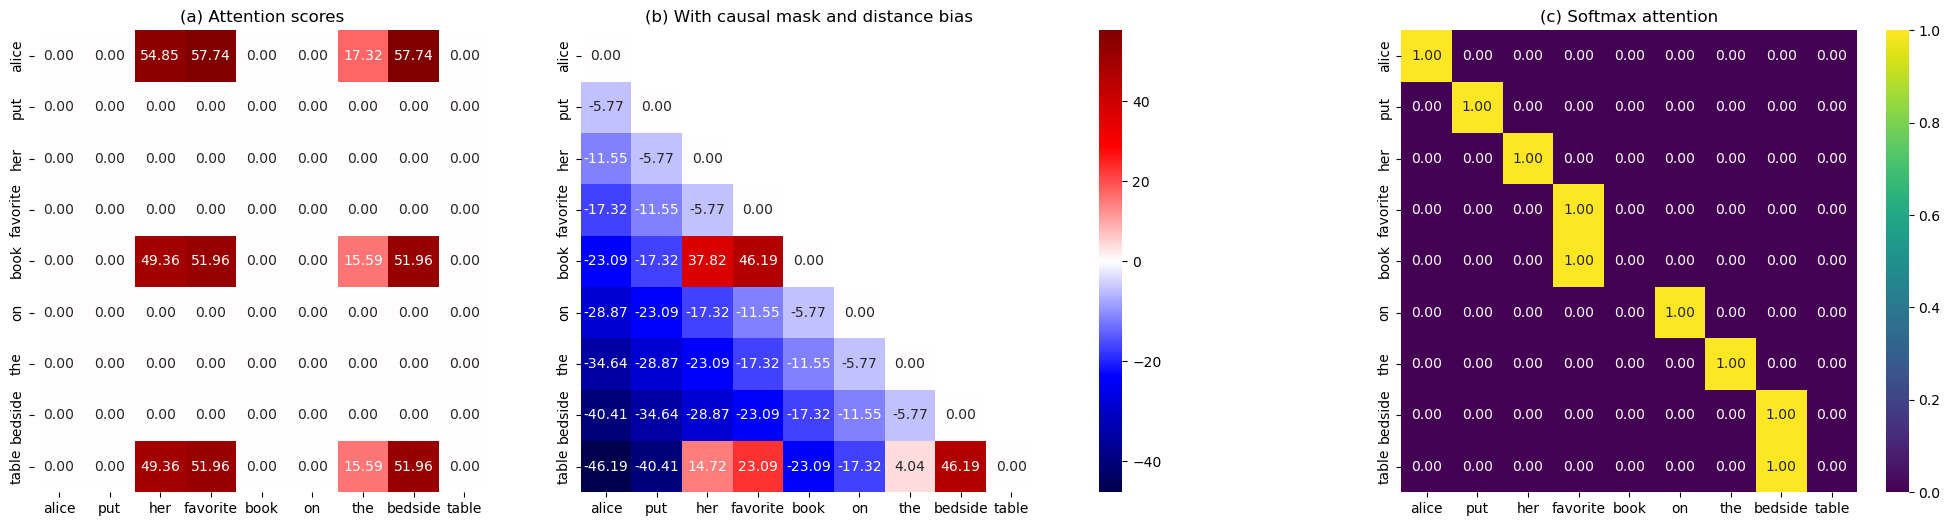

In [217]:
df1 = get_attention_matrix(
    sentence=s1,
    head_name="description",
    distance_bias=False,
    mask=False,
    softmax=False,
)
df2 = get_attention_matrix(
    sentence=s1,
    head_name="description",
    distance_bias=True,
    mask=True,
    softmax=False,
)
df3 = get_attention_matrix(
    sentence=s1,
    head_name="description",
    distance_bias=True,
    mask=True,
    softmax=True,
)

vmin = min([np.nanmin(df.values) for df in [df1, df2]])
vmax = max([np.nanmax(df.values) for df in [df1, df2]])

from matplotlib.colors import TwoSlopeNorm
fig, axes = plt.subplots(1, 3, figsize=(25, 6))
norm = TwoSlopeNorm(
    vmin=vmin,
    vcenter=0,
    vmax=vmax,
)

sns.heatmap(
    df1,
    annot=True,
    fmt=".2f",
    cmap="seismic",
    norm=norm,
    vmin=vmin,
    vmax=vmax,
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("(a) Attention scores")
sns.heatmap(
    df2,
    annot=True,
    fmt=".2f",
    cmap="seismic",
    norm=norm,
    vmin=vmin,
    vmax=vmax,
    cbar=False,
    ax=axes[1],
)
axes[1].set_title("(b) With causal mask and distance bias")
sns.heatmap(
    df3,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    ax=axes[2],
)
axes[2].set_title("(c) Softmax attention")
sm = plt.cm.ScalarMappable(
    cmap="seismic",
    norm=norm
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[axes[0], axes[1]])
cbar.outline.set_linewidth(0)

fig.savefig('fig_att.png')
plt.show()

In [218]:
sentence = s1

embedding = np.array([vocab[word] for word in sentence])
W_Q, W_K, W_V, bias_strength = get_W(head_name='description')

Q = embedding @ W_Q
K = embedding @ W_K
V = embedding @ W_V

_, _, out_embeddings = get_attention(
    Q, K, V,
    mask=mask,
    bias_strength=bias_strength if distance_bias else 0.0)

import pandas as pd
import numpy as np

df = pd.DataFrame(
    np.hstack([embedding, out_embeddings]),
    index=sentence,
    columns=pd.MultiIndex.from_product(
        [
            ["Input", "Output"],
            ["Dim 1", "Dim 2", "Dim 3"]
        ]
    )
)

display(df)

Input                       Output                  
             Dim 1     Dim 2     Dim 3    Dim 1    Dim 2    Dim 3
alice    10.000000  0.000000  0.000000 0.000000 9.986439 0.000000
put       0.000000  0.000000  0.000000 3.111111 3.611111 1.111111
her       0.000000  9.500000  0.000000 3.111111 3.611111 1.111111
favorite  0.000000 10.000000  0.000000 3.111111 3.611111 1.111111
book      9.000000  0.000000  0.000000 0.000000 9.982063 0.000000
on        0.000000  0.000000 10.000000 3.111111 3.611111 1.111111
the       0.000000  3.000000  0.000000 3.111111 3.611111 1.111111
bedside   0.000000 10.000000  0.000000 3.111111 3.611111 1.111111
table     9.000000  0.000000  0.000000 0.000000 9.982063 0.000000